In [18]:
import math
import matplotlib.pyplot as plt

In [19]:
# ──────────────────────────────────────────────
#  КОНСТАНТЫ
# ──────────────────────────────────────────────
EPS = 1e-4
MAX_ITER = 100

In [20]:
# ──────────────────────────────────────────────
#  ФУНКЦИИ
# ──────────────────────────────────────────────
def f1(x, y):
    return math.cos(x - 1) + y - 0.8

def f2(x, y):
    return x - math.cos(y) - 2

In [ ]:
# ──────────────────────────────────────────────
#  ГРАФИК
# ──────────────────────────────────────────────
def plot_graphs():
    # Генерация точек для: y = 0.8 - cos(x - 1)
    x_vals = [i * 0.05 for i in range(20, 60)] # x from 1 to 3
    y_vals_1 = [0.8 - math.cos(x - 1) for x in x_vals]
    
    # Генерация точек для: x = 2 + cos(y)
    # диапазон значений y приблизительно от -0.2 до 1.8
    y_vals_2 = [i * 0.05 for i in range(-4, 40)] 
    x_vals_2 = [2 + math.cos(y) for y in y_vals_2]
    
    plt.figure(figsize=(8, 6))
    plt.plot(x_vals, y_vals_1, label='y = 0.8 - cos(x - 1)', color='blue')
    plt.plot(x_vals_2, y_vals_2, label='x = 2 + cos(y)', color='red')
    
    plt.grid(True)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Graphical Solution of the System')
    plt.legend()
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.show()

In [ ]:
# ──────────────────────────────────────────────
#  МЕТОД ПРОСТОЙ ИТЕРАЦИИ
# ──────────────────────────────────────────────
def simple_iteration(x0, y0, eps):
    x, y = x0, y0
    print(f"{'Итерация':<5} | {'x':<10} | {'y':<10} | {'dx':<10} | {'dy':<10}")
    print("-" * 50)
    
    for k in range(MAX_ITER):
        
        x_new = 2 + math.cos(y)
        y_new = 0.8 - math.cos(x_new - 1) 
        
        dx = abs(x_new - x)
        dy = abs(y_new - y)
        
        print(f"{k:<5} | {x_new:<10.6f} | {y_new:<10.6f} | {dx:<10.2e} | {dy:<10.2e}")
        
        if dx < eps and dy < eps:
            return x_new, y_new, k
        
        x, y = x_new, y_new
        
    return x, y, MAX_ITER

In [ ]:
# ──────────────────────────────────────────────
#  МЕТОД НЬЮТОНА
# ──────────────────────────────────────────────
def newton_method(x0, y0, eps):
    x, y = x0, y0
    print(f"{'Итерация':<5} | {'x':<10} | {'y':<10} | {'norm(F)':<10}")
    print("-" * 50)

    for k in range(MAX_ITER):
        # Подсчет ф-ции
        F1 = f1(x, y)
        F2 = f2(x, y)
        
        # Подсчет Якобиана
        # J = [ [-sin(x-1), 1], [1, sin(y)] ]
        j11 = -math.sin(x - 1)
        j12 = 1.0
        j21 = 1.0
        j22 = math.sin(y)
        
        # Решение, используя правила Крамера
        det = j11 * j22 - j12 * j21
        
        if abs(det) < 1e-12:
            print("Determinant is too small! Stopping.")
            break
            
        # delta_x = det([-F1, j12], [-F2, j22]) / det
        # delta_y = det([j11, -F1], [j21, -F2]) / det
        
        dx = ((-F1) * j22 - j12 * (-F2)) / det
        dy = (j11 * (-F2) - (-F1) * j21) / det
        
        x_new = x + dx
        y_new = y + dy
        
        norm_F = math.sqrt(F1**2 + F2**2)
        
        if k < 10:
            print(f"{k:<5} | {x_new:<10.6f} | {y_new:<10.6f} | {norm_F:<10.2e}")
            
        if abs(dx) < eps and abs(dy) < eps:
            return x_new, y_new, k
            
        x, y = x_new, y_new
        
    return x, y, MAX_ITER

In [24]:
# ──────────────────────────────────────────────
#  ПРОВЕРКА КОРРЕКТНОСТИ
# ──────────────────────────────────────────────
def verify_solution(x, y):
    val1 = f1(x, y)
    val2 = f2(x, y)
    print(f"\nПроверка x={x:.6f}, y={y:.6f}:")
    print(f"f1(x,y) = {val1:.2e}")
    print(f"f2(x,y) = {val2:.2e}")
    if abs(val1) < EPS and abs(val2) < EPS:
        print("Решение правильное")
    else:
        print("Точность решения модет быть низкой")

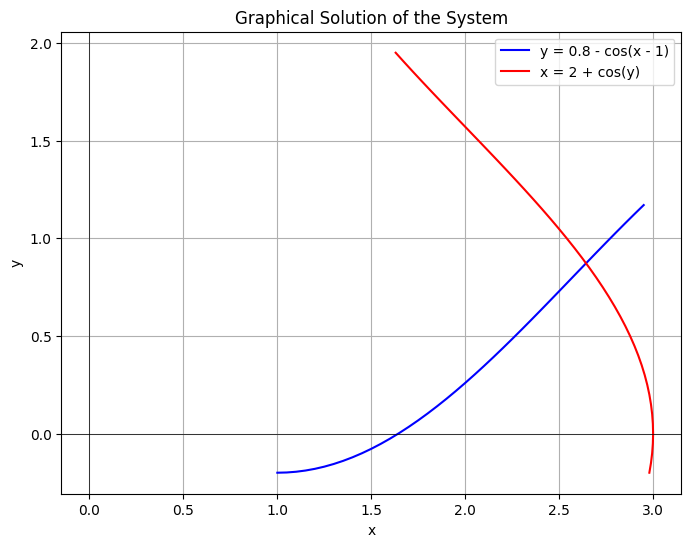


--- Метод простой итерации ---
Итерация | x          | y          | dx         | dy        
--------------------------------------------------
0     | 2.696707   | 0.925578   | 1.97e-01   | 1.26e-01  
1     | 2.601373   | 0.830572   | 9.53e-02   | 9.50e-02  
2     | 2.674454   | 0.903472   | 7.31e-02   | 7.29e-02  
3     | 2.618887   | 0.848072   | 5.56e-02   | 5.54e-02  
4     | 2.661431   | 0.890510   | 4.25e-02   | 4.24e-02  
5     | 2.629015   | 0.858186   | 3.24e-02   | 3.23e-02  
6     | 2.653811   | 0.882919   | 2.48e-02   | 2.47e-02  
7     | 2.634898   | 0.864058   | 1.89e-02   | 1.89e-02  
8     | 2.649357   | 0.878479   | 1.45e-02   | 1.44e-02  
9     | 2.638322   | 0.867475   | 1.10e-02   | 1.10e-02  
10    | 2.646755   | 0.875885   | 8.43e-03   | 8.41e-03  
11    | 2.640317   | 0.869465   | 6.44e-03   | 6.42e-03  
12    | 2.645236   | 0.874370   | 4.92e-03   | 4.91e-03  
13    | 2.641480   | 0.870625   | 3.76e-03   | 3.75e-03  
14    | 2.644349   | 0.873486   | 2.87e-03  

In [25]:
if __name__ == "__main__":
    plot_graphs()
    
    # Начальное приближение, но на графике видно что x ~ 2.6, y ~ 0.9
    x0, y0 = 2.5, 0.8
    
    print("\n--- Метод простой итерации ---")
    x_si, y_si, iter_si = simple_iteration(x0, y0, EPS)
    print(f"Результат метод простой итераци: x = {x_si:.6f}, y = {y_si:.6f}, Итерации: {iter_si}")
    verify_solution(x_si, y_si)
    
    print("\n--- Метод Ньютона ---")
    x_newt, y_newt, iter_newt = newton_method(x0, y0, EPS)
    print(f"Результат метода Ньютона: x = {x_newt:.6f}, y = {y_newt:.6f}, Итерации: {iter_newt}")
    verify_solution(x_newt, y_newt)